# Model B with SRGAN-Generated Images

This notebook trains Model B on SRGAN-generated OCT images and evaluates it.

- Training duration: at least 150 epochs
- Checkpoints saved every n epochs
- Final metrics: Accuracy, F1 Score, and ROC-AUC

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Locate the project root directory.
def find_root():
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "notebooks").exists() and (root / "requirements.txt").exists():
            return root
    for root in [Path("/content/OCT-SRGAN")]:
        if root.exists():
            return root
    return cwd

# Resolve SRGAN checkpoint from runtime path.
def find_srgan_generator(root_dir):
    ckpt_path = root_dir / "checkpoints" / "srgan" / "generator_final.pth"
    if ckpt_path.exists():
        return ckpt_path
    raise FileNotFoundError(
        "SRGAN generator checkpoint is missing. Run notebooks/srgan.ipynb first and make sure generator_final.pth exists."
    )

root_dir = find_root()
split_dir = root_dir / "artifacts" / "splits"
ckpt_dir = root_dir / "checkpoints" / "model_b"
ckpt_dir.mkdir(parents=True, exist_ok=True)

# Verify checkpoint directory write access before long training.
try:
    probe_file = ckpt_dir / ".checkpoint_write_test.bin"
    with open(probe_file, "wb") as probe_handle:
        probe_handle.write(b"ok")
    if probe_file.exists():
        probe_file.unlink()
except Exception as exc:
    raise RuntimeError(f"Checkpoint directory is not writable: {ckpt_dir}") from exc

train_csv = split_dir / "train_split.csv"
test_csv = split_dir / "test_split.csv"
if not train_csv.exists() or not test_csv.exists():
    raise FileNotFoundError(
        "Split CSV files are missing. Run notebooks/model_a.ipynb first to create train_split.csv and test_split.csv."
    )

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

gen_path = find_srgan_generator(root_dir)

print("root_dir:", root_dir)
print("model_b checkpoints:", ckpt_dir)
print("SRGAN generator:", gen_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("CUDA ready:", torch.cuda.is_available())

print("Train rows:", len(train_df), "Test rows:", len(test_df))

root_dir: /content/OCT-SRGAN
model_b checkpoints: /content/OCT-SRGAN/checkpoints/model_b
SRGAN generator: /content/OCT-SRGAN/checkpoints/srgan/generator_final.pth
Torch version: 2.10.0+cu128
CUDA ready: True
Train rows: 2261 Test rows: 970


In [4]:
img_size = 128
low_size = 32
batch_size = 32
epochs = 150
save_gap = 25
worker_n = 2
learn_rate = 1e-4

SR train tensor: torch.Size([2261, 3, 128, 128])


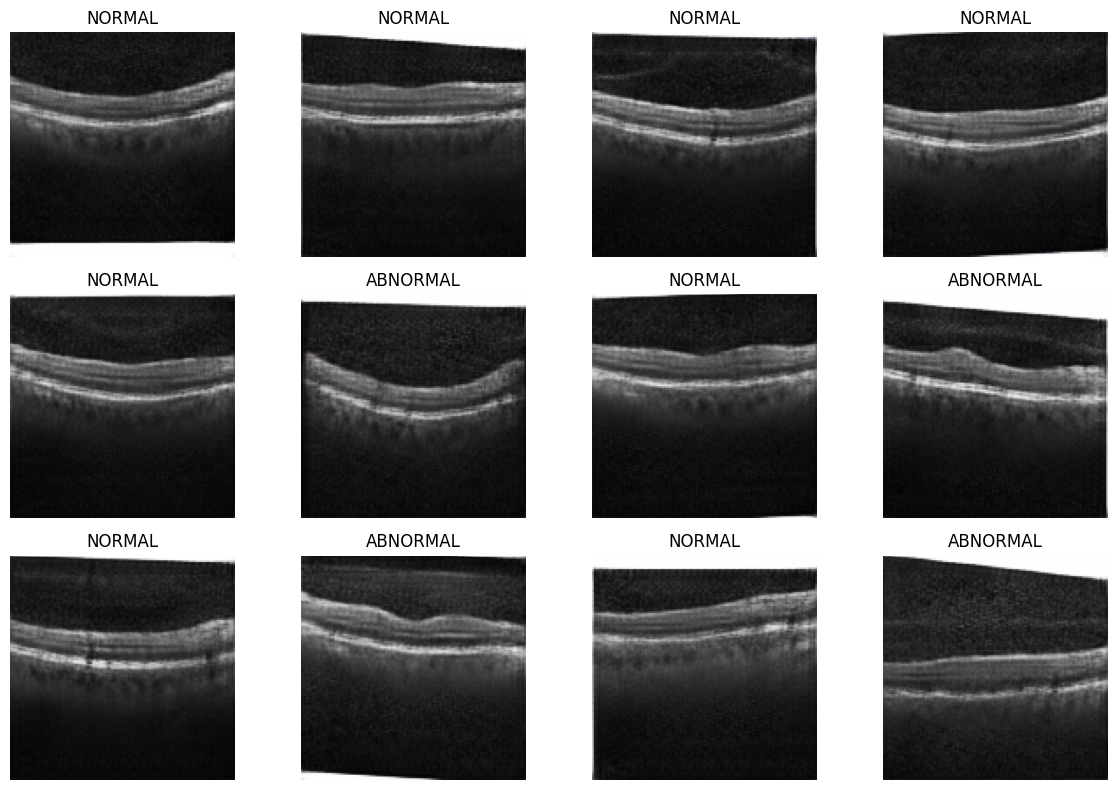

In [5]:
# Residual block used in SRGAN models.
class ResBlock(nn.Module):
    # Initialize class state.
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )

    # Run the forward pass.
    def forward(self, x):
        return x + self.block(x)

# Generator network for super-resolution.
class GenNet(nn.Module):
    # Initialize class state.
    def __init__(self, blocks=8):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(3, 64, 9, 1, 4), nn.PReLU())
        self.body = nn.Sequential(*[ResBlock(64) for _ in range(blocks)])
        self.mid = nn.Sequential(nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64))
        self.up = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.PReLU(),
        )
        self.tail = nn.Sequential(nn.Conv2d(64, 3, 9, 1, 4), nn.Sigmoid())

    # Run the forward pass.
    def forward(self, x):
        skip_feat = self.head(x)
        body_feat = self.body(skip_feat)
        mix_feat = self.mid(body_feat) + skip_feat
        return self.tail(self.up(mix_feat))

# Dataset that loads image paths and labels.
class PathSet(Dataset):
    # Initialize class state.
    def __init__(self, data_df):
        self.data_df = data_df.reset_index(drop=True)
        self.to_img = transforms.ToTensor()
        self.high_tf = transforms.Resize(
            (img_size, img_size),
            interpolation=transforms.InterpolationMode.BICUBIC,
        )

    # Return the dataset size.
    def __len__(self):
        return len(self.data_df)

    # Return a single sample.
    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        high_img = self.to_img(self.high_tf(img))
        return high_img, int(row["bin_label"])

gen_net = GenNet().to(device)
gen_net.load_state_dict(torch.load(gen_path, map_location=device))
gen_net.eval()

# Generate super-resolved tensors from paths.
def make_sr(data_df):
    data_set = PathSet(data_df)
    data_loader = DataLoader(
        data_set,
        batch_size=32,
        shuffle=False,
        num_workers=worker_n,
        pin_memory=True,
    )
    img_list, lab_list = [], []
    with torch.no_grad():
        for high_img, lab in data_loader:
            high_img = high_img.to(device, non_blocking=True)
            low_img = F.interpolate(high_img, size=(low_size, low_size), mode="area")
            super_img = gen_net(low_img).clamp(0, 1).cpu()
            img_list.append(super_img)
            lab_list.append(lab)
    data_x = torch.cat(img_list)
    data_y = torch.cat(lab_list).float()
    return data_x, data_y

train_x, train_y = make_sr(train_df)
print("SR train tensor:", train_x.shape)

plt.figure(figsize=(12, 8))
for idx in range(min(12, train_x.size(0))):
    plt.subplot(3, 4, idx + 1)
    plt.imshow(train_x[idx].permute(1, 2, 0).numpy().clip(0, 1))
    plt.title("ABNORMAL" if int(train_y[idx].item()) == 1 else "NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

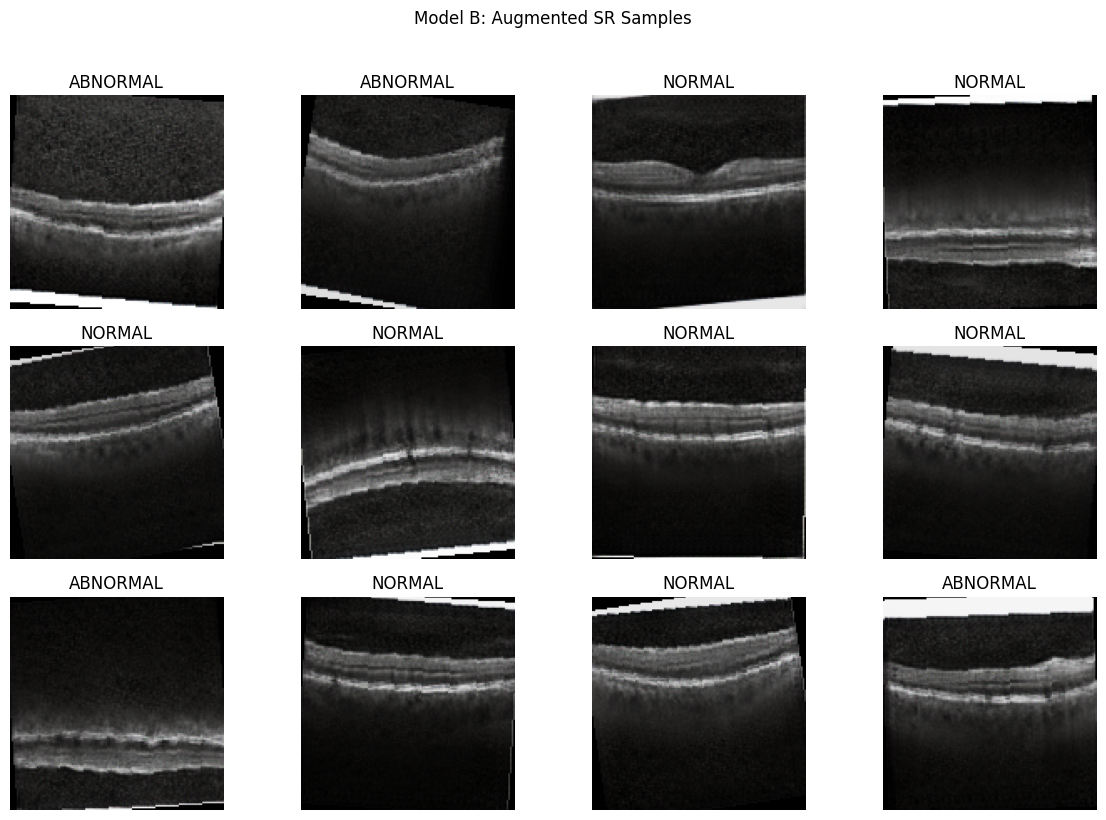

Epoch 001/150 | Train AUC 0.8989
Epoch 002/150 | Train AUC 0.9787
Epoch 003/150 | Train AUC 0.9855
Epoch 004/150 | Train AUC 0.9905
Epoch 005/150 | Train AUC 0.9916
Epoch 006/150 | Train AUC 0.9958
Epoch 007/150 | Train AUC 0.9952
Epoch 008/150 | Train AUC 0.9974
Epoch 009/150 | Train AUC 0.9983
Epoch 010/150 | Train AUC 0.9983
Epoch 011/150 | Train AUC 0.9965
Epoch 012/150 | Train AUC 0.9989
Epoch 013/150 | Train AUC 0.9988
Epoch 014/150 | Train AUC 0.9996
Epoch 015/150 | Train AUC 0.9990
Epoch 016/150 | Train AUC 0.9997
Epoch 017/150 | Train AUC 0.9983
Epoch 018/150 | Train AUC 0.9997
Epoch 019/150 | Train AUC 0.9990
Epoch 020/150 | Train AUC 0.9989
Epoch 021/150 | Train AUC 0.9989
Epoch 022/150 | Train AUC 0.9997
Epoch 023/150 | Train AUC 0.9998
Epoch 024/150 | Train AUC 0.9991
Saved checkpoint: /content/OCT-SRGAN/checkpoints/model_b/model_b_epoch_025.pth
Epoch 025/150 | Train AUC 0.9996
Epoch 026/150 | Train AUC 0.9989
Epoch 027/150 | Train AUC 0.9995
Epoch 028/150 | Train AUC 0.99

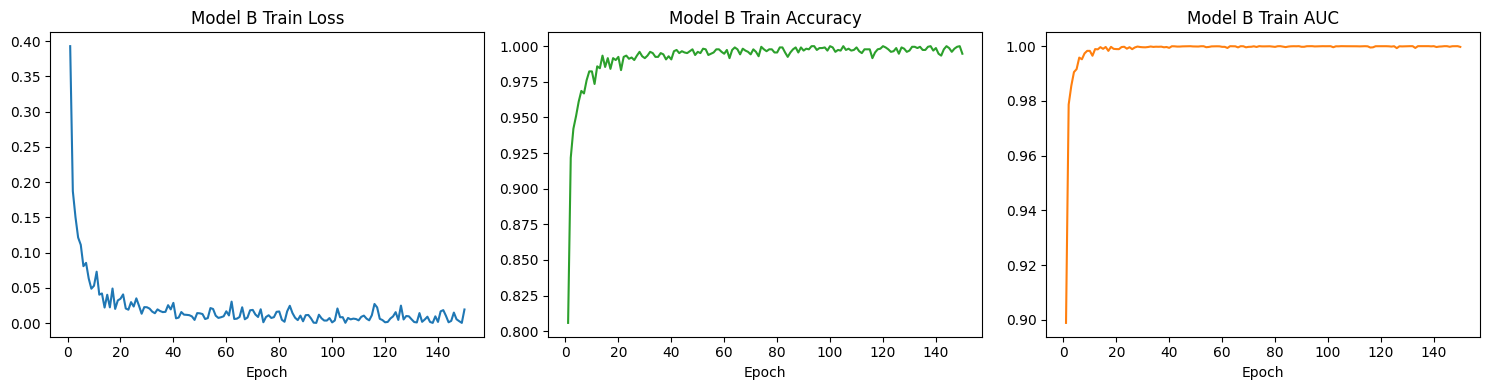

{'accuracy': 0.988659793814433, 'f1': 0.98989898989899, 'auc': 0.9984000415124364}


,path,org_class,bin_label,prob_abnormal,pred_label
0,/content/OCT-SRGAN/data/test/DME/DME15_034.tif,DME,1,1.00000,1
1,/content/OCT-SRGAN/data/train/DRUSEN/AMD7_041.tif,DRUSEN,1,1.00000,1
2,/content/OCT-SRGAN/data/test/DRUSEN/AMD13_031.tif,DRUSEN,1,1.00000,1
3,/content/OCT-SRGAN/data/train/DRUSEN/AMD10_027...,DRUSEN,1,1.00000,1
4,/content/OCT-SRGAN/data/train/DME/DME3_093.tif,DME,1,0.99981,1


In [6]:
img_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
img_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Normalize image tensors for model input.
def norm_img(img_x):
    return (img_x - img_mean) / img_std

# Dataset for augmented SR training samples.
class SRTrainSet(Dataset):
    # Initialize class state.
    def __init__(self, data_x, data_y, aug_on=True):
        self.data_x = data_x
        self.data_y = data_y
        self.aug_on = aug_on
        self.aug_tf = transforms.Compose(
            [
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.10, contrast=0.10),
                transforms.ToTensor(),
            ]
        )

    # Return the dataset size.
    def __len__(self):
        return self.data_x.size(0)

    # Return a single sample.
    def __getitem__(self, idx):
        img_x = self.data_x[idx]
        if self.aug_on:
            img_x = self.aug_tf(img_x)
        return norm_img(img_x), self.data_y[idx]

# Dataset for evaluation samples.
class EvalSet(Dataset):
    # Initialize class state.
    def __init__(self, data_df):
        self.data_df = data_df.reset_index(drop=True)
        self.eval_tf = transforms.Compose(
            [
                transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.ToTensor(),
            ]
        )

    # Return the dataset size.
    def __len__(self):
        return len(self.data_df)

    # Return a single sample.
    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img_x = norm_img(self.eval_tf(img))
        img_y = torch.tensor(float(row["bin_label"]), dtype=torch.float32)
        return img_x, img_y


train_set = SRTrainSet(train_x, train_y, aug_on=True)
test_set = EvalSet(test_df)

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=worker_n,
    pin_memory=True,
)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=worker_n,
    pin_memory=True,
)

# Convert normalized tensors for display.
def denorm_img(img_x):
    return (img_x.cpu() * img_std) + img_mean

aug_x, aug_y = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for idx in range(min(12, aug_x.size(0))):
    plt.subplot(3, 4, idx + 1)
    plt.imshow(denorm_img(aug_x[idx]).permute(1, 2, 0).clamp(0, 1).numpy())
    plt.title("ABNORMAL" if int(aug_y[idx].item()) == 1 else "NORMAL")
    plt.axis("off")
plt.suptitle("Model B: Augmented SR Samples", y=1.02)
plt.tight_layout()
plt.show()

net = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for param in net.features[:-8].parameters():
    param.requires_grad = False
net.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(1024, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
)
net = net.to(device)
loss_fn = nn.BCEWithLogitsLoss()
opt = optim.Adam(filter(lambda param: param.requires_grad, net.parameters()), lr=learn_rate)

# Run one training or evaluation pass.
def run_pass(data_loader, train_on):
    net.train(train_on)
    loss_sum = 0.0
    prob_all, lab_all = [], []

    for img_x, img_y in data_loader:
        img_x = img_x.to(device, non_blocking=True)
        img_y = img_y.to(device, non_blocking=True).view(-1, 1)

        with torch.set_grad_enabled(train_on):
            logits = net(img_x)
            loss = loss_fn(logits, img_y)
            if train_on:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()

        loss_sum += loss.item() * img_x.size(0)
        prob_all.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
        lab_all.append(img_y.detach().cpu().numpy().ravel())

    prob_all = np.concatenate(prob_all)
    lab_all = np.concatenate(lab_all)
    pred_all = (prob_all >= 0.5).astype(int)

    loss_avg = loss_sum / len(data_loader.dataset)
    acc_val = accuracy_score(lab_all, pred_all)
    auc_val = roc_auc_score(lab_all, prob_all)
    return loss_avg, acc_val, auc_val

log_rows = []
for epoch in range(1, epochs + 1):
    loss_val, acc_val, auc_val = run_pass(train_loader, True)
    log_rows.append({"epoch": epoch, "train_loss": loss_val, "train_acc": acc_val, "train_auc": auc_val})
    if epoch % save_gap == 0:
        epoch_ckpt_path = ckpt_dir / f"model_b_epoch_{epoch:03d}.pth"
        torch.save(net.state_dict(), epoch_ckpt_path)
        if not epoch_ckpt_path.exists():
            raise RuntimeError(f"Checkpoint save failed: {epoch_ckpt_path}")
        print(f"Saved checkpoint: {epoch_ckpt_path}")
    print(f"Epoch {epoch:03d}/{epochs} | Train AUC {auc_val:.4f}")

final_ckpt_path = ckpt_dir / "model_b_final.pth"
torch.save(net.state_dict(), final_ckpt_path)
if not final_ckpt_path.exists():
    raise RuntimeError(f"Final checkpoint save failed: {final_ckpt_path}")
print(f"Saved final checkpoint: {final_ckpt_path}")
log_df = pd.DataFrame(log_rows)

fig, axis = plt.subplots(1, 3, figsize=(15, 4))
axis[0].plot(log_df["epoch"], log_df["train_loss"], color="tab:blue")
axis[0].set_title("Model B Train Loss")
axis[0].set_xlabel("Epoch")
axis[1].plot(log_df["epoch"], log_df["train_acc"], color="tab:green")
axis[1].set_title("Model B Train Accuracy")
axis[1].set_xlabel("Epoch")
axis[2].plot(log_df["epoch"], log_df["train_auc"], color="tab:orange")
axis[2].set_title("Model B Train AUC")
axis[2].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

log_df.tail()

net.load_state_dict(torch.load(final_ckpt_path, map_location=device))
net.eval()
prob_all, lab_all = [], []
with torch.no_grad():
    for img_x, img_y in test_loader:
        img_x = img_x.to(device, non_blocking=True)
        logits = net(img_x)
        prob_all.append(torch.sigmoid(logits).cpu().numpy().ravel())
        lab_all.append(img_y.numpy().ravel())

y_prob = np.concatenate(prob_all)
y_true = np.concatenate(lab_all).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

score_b = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "f1": float(f1_score(y_true, y_pred)),
    "auc": float(roc_auc_score(y_true, y_prob)),
}
print(score_b)

score_df = pd.DataFrame([score_b], index=["Model B"])
score_df

pred_df = test_df.copy()
pred_df["prob_abnormal"] = y_prob
pred_df["pred_label"] = y_pred
pred_df.head()